# Advanced Models — LightGBM & XGBoost
**Notebook 05 — IDX Exchange Data Science Internship 2026**

This notebook trains two gradient boosting models, LightGBM and XGBoost, as 
advanced alternatives to the Random Forest baseline. Both models are tuned using 
systematic hyperparameter search and early stopping on a chronological validation set.

**Input:** `train_enriched.csv` and `test_enriched.csv` from Notebook 04  
**Output:** Trained XGBoost model saved via joblib (`xgb_model.pkl`)


In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import random
import xgboost as xgb
np.random.seed(42)

#util functions
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse, "MAE": mae, "MAPE": mape, "MdAPE": mdape}

def make_train_test_split(df, date_col='CloseDate', x_months=12):
    """
    Creates a time-based train/test split.
    
    Parameters:
        df: cleaned dataframe
        date_col: name of the date column to split on
        x_months: number of months to use for training window (tunable)
    
    Returns:
        train_df, test_df
    """
    df[date_col] = pd.to_datetime(df[date_col], format='mixed')
    
    latest_month = df[date_col].dt.to_period('M').max()
    cutoff_month = latest_month - x_months
    
    test_df = df[df[date_col].dt.to_period('M') == latest_month].copy()
    train_df = df[
        (df[date_col].dt.to_period('M') > cutoff_month) &
        (df[date_col].dt.to_period('M') < latest_month)
    ].copy()
    
    print(f"Test month: {latest_month}")
    print(f"Training window: {x_months} months ({cutoff_month} to {latest_month})")
    print(f"Training rows: {len(train_df):,}")
    print(f"Testing rows:  {len(test_df):,}")
    
    return train_df, test_df


def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

## 1. Data Loading & Feature Preparation

The enriched dataset from Notebook 04 is loaded and prepared for modeling:
- Ensured leakage columns removed (ListPrice, DaysOnMarket, etc.)
- Remaining object columns dropped
- Non-California properties filtered from training data
- StateOrProvince columns dropped after filtering (no longer informative)
- Column names cleaned for LightGBM/XGBoost compatibility (special characters replaced)

In [4]:
# Load feature-engineered data

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"

train_full = pd.read_csv(
    filepath + r"\train_enriched.csv",
    low_memory=False
)

test_full = pd.read_csv(
    filepath + r"\test_enriched.csv",
    low_memory=False
)

print(f"Training data: {train_full.shape}")
print(f"Test data:     {test_full.shape}")

Training data: (315683, 62)
Test data:     (12634, 62)


## 2. Train / Validation / Test Split

A proper three-way chronological split is implemented to follow production AVM 
best practices:

| Split | Period | Purpose |
|---|---|---|
| Training | 30 months prior to validation | Model training |
| Validation | Second most recent month (May 2026) | Early stopping & hyperparameter tuning |
| Test | Most recent month (June 2026) | Final evaluation only |

The validation set is carved from the training data chronologically where the most 
recent training month becomes the validation set. This ensures the model is always 
evaluated on data it has never seen and mirrors real-world deployment conditions.

Variables using the `_v` suffix correspond to this validation split to distinguish 
them from the initial data variables.

In [6]:
# Create chronological train / validation / test split

train_full["CloseDate"] = pd.to_datetime(
    train_full["CloseDate"],
    errors="coerce"
)

train_df, test_df = make_train_test_split(
    train_full,
    x_months=30
)

# Most recent month of training data becomes validation set
val_month = train_df["CloseDate"].dt.to_period("M").max()

val_df = train_df[
    train_df["CloseDate"].dt.to_period("M") == val_month
].copy()

train_df = train_df[
    train_df["CloseDate"].dt.to_period("M") < val_month
].copy()

print(f"\nValidation month: {val_month}")
print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Test month: 2026-05
Training window: 30 months (2023-11 to 2026-05)
Training rows: 303,839
Testing rows:  11,844

Validation month: 2026-04
Train: 292,001 rows
Val:   11,838 rows
Test:  11,844 rows


In [7]:
# Prepare features and target

drop_cols = [
    "CloseDate",
    "ListPrice",
    "OriginalListPrice",
    "ListingKey",
    "ListingKeyNumeric",
    "DaysOnMarket",
    "HighSchoolDistrict",
    "DistrictName",
    "DistrictMedianPrice",
    "Latitude_orig",
    "Longitude_orig"
]

x_train = train_df.drop(
    columns=["ClosePrice"] + drop_cols,
    errors="ignore"
)
x_val = val_df.drop(
    columns=["ClosePrice"] + drop_cols,
    errors="ignore"
)
x_test = test_df.drop(
    columns=["ClosePrice"] + drop_cols,
    errors="ignore"
)

y_train = train_df["ClosePrice"]
y_val = val_df["ClosePrice"]
y_test = test_df["ClosePrice"]


# Remove remaining object columns
obj_cols = x_train.select_dtypes(include="object").columns.tolist()

if obj_cols:
    print(f"Dropping object columns: {obj_cols}")

    x_train = x_train.drop(columns=obj_cols)
    x_val = x_val.drop(columns=obj_cols)
    x_test = x_test.drop(columns=obj_cols)


# Filter training data to California
if "StateOrProvince_CA" in x_train.columns:

    ca_mask = x_train["StateOrProvince_CA"] == 1

    print(
        f"Removing {np.sum(~ca_mask):,} "
        "non-CA training rows"
    )

    x_train = x_train[ca_mask]
    y_train = y_train[ca_mask]


# Drop state indicator columns
state_cols = [
    col for col in x_train.columns
    if col.startswith("StateOrProvince")
]

x_train = x_train.drop(columns=state_cols, errors="ignore")
x_val = x_val.drop(columns=state_cols, errors="ignore")
x_test = x_test.drop(columns=state_cols, errors="ignore")


# Clean column names
x_train = clean_col_names(x_train)
x_val = clean_col_names(x_val)
x_test = clean_col_names(x_test)

print(f"\nX_train: {x_train.shape}")
print(f"X_val:   {x_val.shape}")
print(f"X_test:  {x_test.shape}")

Removing 19 non-CA training rows

X_train: (291982, 40)
X_val:   (11838, 40)
X_test:  (11844, 40)


## 3. LightGBM

LightGBM is a gradient boosting framework developed by Microsoft that builds 
trees leaf-wise rather than level-wise, making it faster and more memory efficient 
than traditional gradient boosting on large datasets.

**Tuning approach:**
1. Default parameters as a baseline
2. Manual tuning of `n_estimators`, `max_depth`, and `learning_rate`
3. Early stopping with 3,000 estimators — training stops automatically when 
   validation performance stops improving for 50 consecutive rounds
4. Secondary tuning of `num_leaves`, `min_child_samples`, `subsample`, 
   and `colsample_bytree`

**Key parameters:**
- `n_estimators` — maximum number of trees (early stopping finds optimal count)
- `max_depth` — maximum depth of each tree
- `learning_rate` — contribution of each tree to the final prediction
- `num_leaves` — maximum number of leaf nodes per tree (LightGBM's most important parameter)
- `subsample` / `colsample_bytree` — fraction of rows/columns used per tree (adds regularization)

In [9]:
# LightGBM baseline

lgbm_baseline = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_baseline.fit(x_train, y_train)
y_val_pred_lgbm = lgbm_baseline.predict(x_val)
results_lgbm_baseline = evaluate_model(
    y_val,
    y_val_pred_lgbm,
    label="LightGBM (baseline, validation)"
)


LightGBM (baseline, validation)
R²:    0.8626
RMSE:  $341,492
MAE:   $199,759
MAPE:  16.92%
MdAPE: 12.17%


In [10]:
# Initial LightGBM hyperparameter tuning

lgbm_param_combos = [
    {
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.10
    },
    {
        "n_estimators": 1000,
        "max_depth": 5,
        "learning_rate": 0.05
    },
    {
        "n_estimators": 500,
        "max_depth": 7,
        "learning_rate": 0.10
    }
]

lgbm_tuning_results = []
for params in lgbm_param_combos:
    model = lgb.LGBMRegressor(
        **params,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    model.fit(x_train, y_train)
    y_val_pred = model.predict(x_val)
    r2 = r2_score(y_val, y_val_pred)
    mdape = np.median(
        np.abs((y_val - y_val_pred) / y_val)
    ) * 100
    lgbm_tuning_results.append({
        **params,
        "R2": r2,
        "MdAPE": mdape
    })

lgbm_initial_results = pd.DataFrame(lgbm_tuning_results)
lgbm_initial_results.sort_values(
    "MdAPE"
)

,n_estimators,max_depth,learning_rate,R2,MdAPE
2,500,7,0.10,0.896427,9.794262
0,500,5,0.10,0.888156,10.061061
1,1000,5,0.05,0.887674,10.064884


In [11]:
# LightGBM with early stopping
lgbm_es = lgb.LGBMRegressor(
    n_estimators=3000,
    max_depth=7,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm_es.fit(
    x_train,
    y_train,
    eval_set=[(x_val, y_val)],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=False
        )
    ]
)

print( f"Best number of trees: " f"{lgbm_es.best_iteration_}")
y_val_pred_lgbm_es = lgbm_es.predict(x_val)
results_lgbm_es = evaluate_model(
    y_val,
    y_val_pred_lgbm_es,
    label="LightGBM (early stopping, validation)"
)

C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Best number of trees: 2983

LightGBM (early stopping, validation)
R²:    0.9052
RMSE:  $283,632
MAE:   $155,177
MAPE:  12.47%
MdAPE: 8.69%


In [12]:
# Secondary LightGBM hyperparameter tuning

lgbm_secondary_combos = [
    {
        "num_leaves": 63,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "num_leaves": 127,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "num_leaves": 63,
        "min_child_samples": 50,
        "subsample": 0.7,
        "colsample_bytree": 0.7
    },
    {
        "num_leaves": 127,
        "min_child_samples": 50,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    }
]

lgbm_secondary_results = []
for params in lgbm_secondary_combos:
    model = lgb.LGBMRegressor(
        n_estimators=2000,
        max_depth=7,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **params
    )
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_val, y_val)],
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=50,
                verbose=False
            )
        ]
    )

    y_val_pred = model.predict(x_val)
    r2 = r2_score(y_val, y_val_pred)
    mdape = np.median(
        np.abs((y_val - y_val_pred) / y_val)
    ) * 100
    lgbm_secondary_results.append({
        **params,
        "best_trees": model.best_iteration_,
        "R2": r2,
        "MdAPE": mdape
    })

lgbm_secondary_df = pd.DataFrame(lgbm_secondary_results)
lgbm_secondary_df.sort_values("MdAPE")

C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\julia\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

,num_leaves,min_child_samples,subsample,colsample_bytree,best_trees,R2,MdAPE
1,127,20,0.8,0.8,1996,0.906950,8.397701
0,63,20,0.8,0.8,2000,0.905603,8.461579
3,127,50,0.9,0.9,2000,0.905149,8.480883
2,63,50,0.7,0.7,1993,0.905047,8.598365


In [13]:
# Selecting best LightGBM configuration
best_lgbm_params = (
    lgbm_secondary_df
    .sort_values("MdAPE")
    .iloc[0]
)
print("Best LightGBM configuration:")
print(best_lgbm_params)

Best LightGBM configuration:
num_leaves            127.000000
min_child_samples      20.000000
subsample               0.800000
colsample_bytree        0.800000
best_trees           1996.000000
R2                      0.906950
MdAPE                   8.397701
Name: 1, dtype: float64


In [14]:
# Final LightGBM model
lgbm_final = lgb.LGBMRegressor(
    n_estimators=int(best_lgbm_params["best_trees"]),
    max_depth=7,
    learning_rate=0.05,
    num_leaves=int(best_lgbm_params["num_leaves"]),
    min_child_samples=int(
        best_lgbm_params["min_child_samples"]
    ),
    subsample=best_lgbm_params["subsample"],
    colsample_bytree=best_lgbm_params["colsample_bytree"],
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_final.fit(x_train, y_train)

# final LightGBM evaluation on untouched test set
y_pred_lgbm_final = lgbm_final.predict(x_test)
results_lgbm_final = evaluate_model(
    y_test,
    y_pred_lgbm_final,
    label="LightGBM (final test)"
)


LightGBM (final test)
R²:    0.9052
RMSE:  $282,443
MAE:   $153,019
MAPE:  11.92%
MdAPE: 8.36%


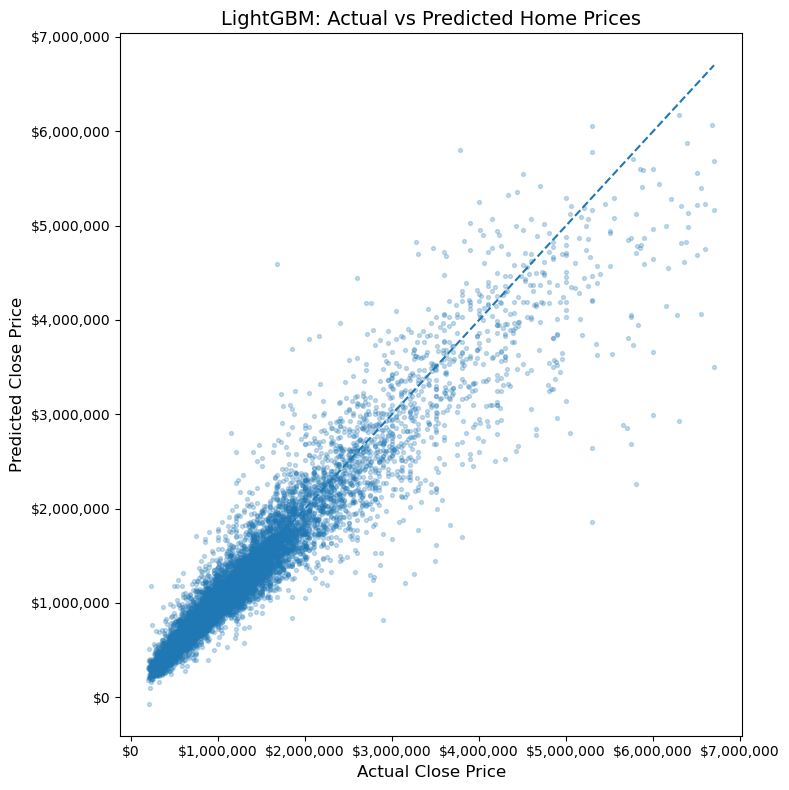

In [15]:
# LightGBM: Actual vs Predicted

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_lgbm_final, alpha=0.25, s=8)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--", linewidth=1.5, color="red")

ax.set_xlabel("Actual Close Price", fontsize=12)
ax.set_ylabel("Predicted Close Price", fontsize=12)
ax.set_title(
    "LightGBM: Actual vs Predicted Home Prices",
    fontsize=14
)

ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.savefig(filepath + r"\lgbm_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

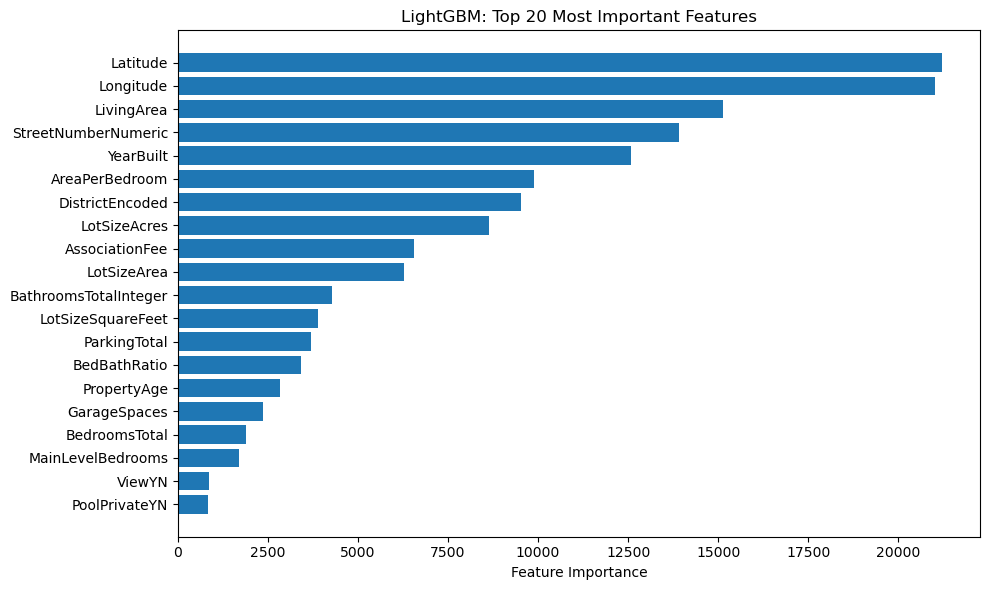

In [16]:
# LightGBM feature importance

lgbm_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": lgbm_final.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))
plt.barh(lgbm_importance["Feature"][::-1], lgbm_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("LightGBM: Top 20 Most Important Features")
plt.tight_layout()
plt.savefig(filepath + r"\lgbm_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. XGBoost

XGBoost is a gradient boosting model that builds trees sequentially, with each 
new tree correcting the errors of the previous ones. It is one of the most widely 
used models in competitive machine learning and real-world AVM systems.

Unlike LightGBM, XGBoost uses the **chronological validation set** (May 2026) for 
early stopping, following the IDX best practices guideline that hyperparameter 
tuning should never use the test set.

**Tuning approach:**
Three rounds of manual hyperparameter search, progressively narrowing in on the 
best combination of `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree`.
Early stopping automatically determines the optimal number of trees for each combination.

**Final parameters selected:**
- `max_depth=11`
- `learning_rate=0.05`
- `subsample=0.9`
- `colsample_bytree=0.8`
- `~1,029 trees` (determined by early stopping)

In [18]:
# XGBoost baseline with early stopping

xgb_baseline = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="rmse"
)

xgb_baseline.fit(
    x_train,
    y_train,
    eval_set=[(x_val, y_val)],
    verbose=False
)

print(f"Best number of trees: " f"{xgb_baseline.best_iteration}")
y_val_pred_xgb = xgb_baseline.predict(x_val)
results_xgb_baseline = evaluate_model(
    y_val,
    y_val_pred_xgb,
    label="XGBoost (baseline, validation)"
)

Best number of trees: 2958

XGBoost (baseline, validation)
R²:    0.9098
RMSE:  $276,674
MAE:   $148,895
MAPE:  11.84%
MdAPE: 8.22%


In [19]:
# XGBoost hyperparameter tuning

xgb_param_combos = [
    {
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 7,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 7,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.6
    },
    {
        "max_depth": 7,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 9,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 9,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 9,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.9
    },
    {
        "max_depth": 9,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 11,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 11,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.9
    },
    {
        "max_depth": 11,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 11,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "max_depth": 13,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

xgb_tuning_results = []
for params in xgb_param_combos:
    model = xgb.XGBRegressor(
        n_estimators=3000,
        early_stopping_rounds=50,
        eval_metric="rmse",
        random_state=42,
        n_jobs=-1,
        **params
    )
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_val, y_val)],
        verbose=False
    )

    y_val_pred = model.predict(x_val)
    r2 = r2_score(y_val, y_val_pred)
    mdape = np.median(
        np.abs((y_val - y_val_pred) / y_val)
    ) * 100
    xgb_tuning_results.append({
        **params,
        "best_trees": model.best_iteration,
        "R2": r2,
        "MdAPE": mdape
    })

xgb_tuning_df = pd.DataFrame(
    xgb_tuning_results
)
xgb_tuning_df.sort_values("MdAPE")

,max_depth,learning_rate,subsample,colsample_bytree,best_trees,R2,MdAPE
12,13,0.05,0.8,0.8,463,0.905946,7.630123
8,11,0.05,0.8,0.8,917,0.908567,7.662002
11,11,0.03,0.8,0.8,1443,0.911050,7.691973
9,11,0.05,0.8,0.9,764,0.910495,7.700055
10,11,0.05,0.9,0.8,1029,0.910154,7.767507
4,9,0.05,0.8,0.8,1639,0.911280,7.829862
6,9,0.05,0.8,0.9,1504,0.909023,7.862236
5,9,0.05,0.9,0.8,1319,0.910470,7.946199
7,9,0.03,0.8,0.8,2101,0.911054,7.958755
1,7,0.05,0.8,0.8,2958,0.909829,8.219626


In [40]:
# Final XGBoost model

xgb_final = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=11,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    x_train,
    y_train,
    eval_set=[(x_val, y_val)],
    verbose=False
)

print(f"Best trees: {xgb_final.best_iteration}")

Best trees: 1029


In [59]:
# Evaluate final XGBoost model

y_pred_xgb_test = xgb_final.predict(x_test)

r2_xgb_test = r2_score(
    y_test,
    y_pred_xgb_test
)

rmse_xgb_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb_test
    )
)

mae_xgb_test = mean_absolute_error(
    y_test,
    y_pred_xgb_test
)

mape_xgb_test = np.mean(
    np.abs(
        (y_test - y_pred_xgb_test) / y_test
    )
) * 100

mdape_xgb_test = np.median(
    np.abs(
        (y_test - y_pred_xgb_test) / y_test
    )
) * 100

print(f"Test R²: {r2_xgb_test:.6f}")
print(f"Test RMSE: ${rmse_xgb_test:,.0f}")
print(f"Test MAE: ${mae_xgb_test:,.0f}")
print(f"Test MAPE: {mape_xgb_test:.6f}%")
print(f"Test MdAPE: {mdape_xgb_test:.6f}%")

Test R²: 0.906980
Test RMSE: $279,826
Test MAE: $147,190
Test MAPE: 11.192496%
Test MdAPE: 7.657092%


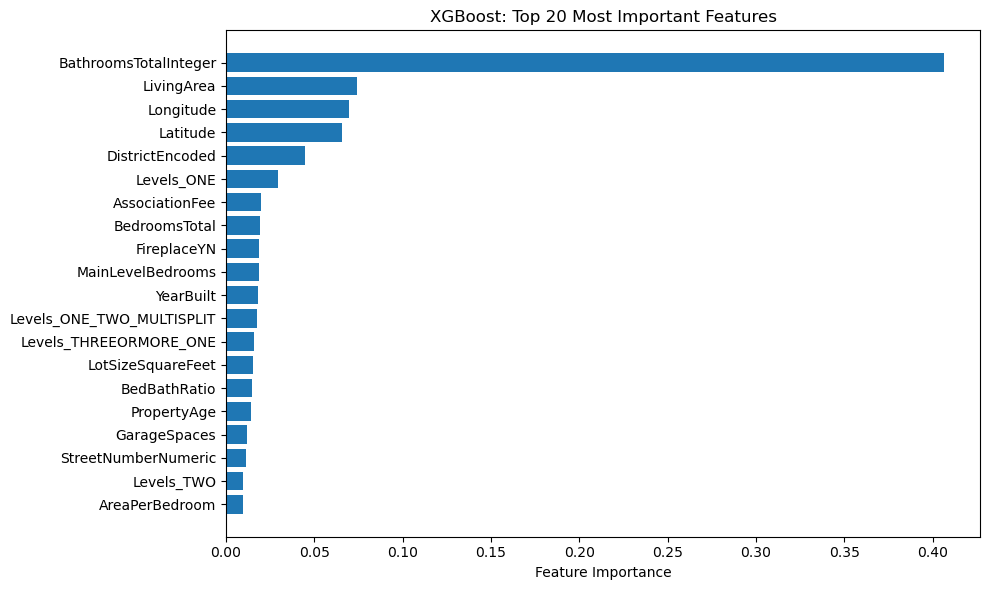

In [61]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb_final.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).head(20)
plt.figure(figsize=(10, 6))
plt.barh(
    xgb_importance["Feature"][::-1],
    xgb_importance["Importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.title("XGBoost: Top 20 Most Important Features")
plt.tight_layout()
plt.savefig( filepath + r"\xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Comparison

The final test-set performance of the advanced models is compared with the baseline models from the previous notebooks.

The test set is used only after model selection has been completed.

In [64]:
# Update XGBoost results in comparison table

comparison.loc["XGBoost (final test)", "R2"] = r2_xgb_test
comparison.loc["XGBoost (final test)", "RMSE"] = rmse_xgb_test
comparison.loc["XGBoost (final test)", "MAE"] = mae_xgb_test
comparison.loc["XGBoost (final test)", "MAPE"] = mape_xgb_test
comparison.loc["XGBoost (final test)", "MdAPE"] = mdape_xgb_test


# Formatted comparison table

comparison_display = comparison.copy()

comparison_display["R²"] = comparison_display["R2"].map(
    "{:.4f}".format
)

comparison_display["RMSE"] = comparison_display["RMSE"].map(
    "${:,.0f}".format
)

comparison_display["MAE"] = comparison_display["MAE"].map(
    "${:,.0f}".format
)

comparison_display["MAPE"] = comparison_display["MAPE"].map(
    "{:.2f}%".format
)

comparison_display["MdAPE"] = comparison_display["MdAPE"].map(
    "{:.2f}%".format
)

comparison_display = comparison_display[
    ["R²", "RMSE", "MAE", "MAPE", "MdAPE"]
]

comparison_display.style.set_properties(
    **{
        "text-align": "center",
        "font-size": "12pt"
    }
).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("font-size", "12pt"),
            ("font-weight", "bold")
        ]
    }
])

,R²,RMSE,MAE,MAPE,MdAPE
Model,,,,,
Linear Regression,0.4787,"$653,574","$436,431",43.73%,30.42%
Decision Tree,0.7814,"$423,219","$242,696",19.73%,13.87%
Random Forest,0.8806,"$312,748","$167,504",13.20%,8.95%
LightGBM (final test),0.9052,"$282,443","$153,019",11.92%,8.36%
XGBoost (final test),0.9070,"$279,826","$147,190",11.19%,7.66%


## 6. Final Model Selection

The final model is selected based on performance on the untouched test set. MdAPE is emphasized because it measures the median percentage error and is directly interpretable as a typical prediction error relative to the property's sale price.

R², MAE, RMSE, and MAPE are also considered to provide a broader assessment of model performance.

In [67]:
# Identify the best-performing model by MdAPE

best_model = comparison.loc[
    comparison["MdAPE"].idxmin()
]

print(f"Best model by MdAPE: {best_model.name}")
print(f"R²:    {best_model['R2']:.4f}")
print(f"RMSE:  ${best_model['RMSE']:,.0f}")
print(f"MAE:   ${best_model['MAE']:,.0f}")
print(f"MAPE:  {best_model['MAPE']:.2f}%")
print(f"MdAPE: {best_model['MdAPE']:.2f}%")

Best model by MdAPE: XGBoost (final test)
R²:    0.9070
RMSE:  $279,826
MAE:   $147,190
MAPE:  11.19%
MdAPE: 7.66%
